# OpenDataBattle2026 Phase2 データ加工【空気】- 湿度

#### [1]読み込み
#### [2]前処理
#### [3]集計

##### 「湿度」より、以下2つの指標を採用。
- 47都市平均との差 (√平方和　→　ユークリッド距離)　
- 盛岡と各都市の相関係数

## 【読み込み】

### ライブラリ読み込み

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 日本語用フォント設定
plt.rcParams["font.family"] = "Meiryo"

### データ読み込み

In [2]:
# 県庁所在地一覧
df_prefectural_capitals = pd.read_csv("../data/raw_00_reference_県庁所在地一覧_20260803.csv", encoding='shift_jis')

# 湿度データ
df_air = pd.read_csv("../data/raw_02_atmospheric_観測地点別湿度データ_20260828.csv", encoding='shift_jis', skiprows=2)
# 気温データ
df_air_temp = pd.read_csv("../data/raw_02_atmospheric_観測地点別気温データ_20260828.csv", encoding='shift_jis', skiprows=2)

## 【データ確認】

### 県庁所在地一覧データ

In [3]:
# 末尾３件確認
df_prefectural_capitals.tail(3)

,コード,都道府県,県庁所在地,ローマ字
44,45,宮崎県,宮崎市,miyazaki
45,46,鹿児島県,鹿児島市,kagoshima
46,47,沖縄県,那覇市,naha


In [4]:
# 概要
df_prefectural_capitals.info()

<class 'pandas.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   コード     47 non-null     int64
 1   都道府県    47 non-null     str  
 2   県庁所在地   47 non-null     str  
 3   ローマ字    47 non-null     str  
dtypes: int64(1), str(3)
memory usage: 1.6 KB


### 湿度データ

In [5]:
# 頭３件確認
df_air.head(3)

,Unnamed: 0,青森,青森.1,青森.2,青森.3,青森.4,青森.5,青森.6,青森.7,青森.8,...,鹿児島.8,那覇,那覇.1,那覇.2,那覇.3,那覇.4,那覇.5,那覇.6,那覇.7,那覇.8
0,年月,平均蒸気圧(hPa),平均蒸気圧(hPa),平均蒸気圧(hPa),平均湿度(％),平均湿度(％),平均湿度(％),最小相対湿度(％),最小相対湿度(％),最小相対湿度(％),...,最小相対湿度(％),平均蒸気圧(hPa),平均蒸気圧(hPa),平均蒸気圧(hPa),平均湿度(％),平均湿度(％),平均湿度(％),最小相対湿度(％),最小相対湿度(％),最小相対湿度(％)
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,品質情報,均質番号,NaN,品質情報,均質番号,NaN,品質情報,均質番号,...,均質番号,NaN,品質情報,均質番号,NaN,品質情報,均質番号,NaN,品質情報,均質番号


In [6]:
# 概要
df_air.info()

<class 'pandas.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Columns: 424 entries, Unnamed: 0 to 那覇.8
dtypes: str(424)
memory usage: 53.1 KB


### 気温データ

In [7]:
# 末尾３件確認
df_air_temp.tail(3)

,Unnamed: 0,青森,青森.1,青森.2,盛岡,盛岡.1,盛岡.2,札幌,札幌.1,札幌.2,...,熊本.2,宮崎,宮崎.1,宮崎.2,鹿児島,鹿児島.1,鹿児島.2,那覇,那覇.1,那覇.2
12,2026/6,18.2,8,1,19.6,8,1,18.5,8,1,...,1,23.4,8,1,24.5,8,1,26.7,8,1
13,2026/7,23.7,8,1,24.3,8,1,22.6,8,1,...,1,29.5,8,1,29.9,8,1,29.3,8,1
14,2026/8,24.6,8,1,24.3,8,1,23.5,8,1,...,1,28.6,8,1,29.8,8,1,28.9,8,1


In [8]:
# 概要
df_air_temp.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Columns: 142 entries, Unnamed: 0 to 那覇.2
dtypes: str(142)
memory usage: 16.8 KB


## 【前処理】

### 県庁所在地データ

In [9]:
### 東京都の県庁所在地が「東京都」になっているので「東京」に変更
df_prefectural_capitals["県庁所在地"] = df_prefectural_capitals["県庁所在地"].replace(
    "東京都", "東京"
)
df_prefectural_capitals["県庁所在地"].unique()

<StringArray>
[  '札幌市',   '青森市',   '盛岡市',   '仙台市',   '秋田市',   '山形市',   '福島市',   '水戸市',
  '宇都宮市',   '前橋市', 'さいたま市',   '千葉市',    '東京',   '横浜市',   '新潟市',   '富山市',
   '金沢市',   '福井市',   '甲府市',   '長野市',   '岐阜市',   '静岡市',  '名古屋市',    '津市',
   '大津市',   '京都市',   '大阪市',   '神戸市',   '奈良市',  '和歌山市',   '鳥取市',   '松江市',
   '岡山市',   '広島市',   '山口市',   '徳島市',   '高松市',   '松山市',   '高知市',   '福岡市',
   '佐賀市',   '長崎市',   '熊本市',   '大分市',   '宮崎市',  '鹿児島市',   '那覇市']
Length: 47, dtype: str

In [10]:
# 結合キー用に都市名から"市"を抜いた列を作成
### 末尾についた"市"だけ削除removesuffix()
df_prefectural_capitals["都市"] = (
    df_prefectural_capitals["県庁所在地"]
    .str.removesuffix("市")
)
df_prefectural_capitals.head()

,コード,都道府県,県庁所在地,ローマ字,都市
0,1,北海道,札幌市,sapporo,札幌
1,2,青森県,青森市,aomori,青森
2,3,岩手県,盛岡市,morioka,盛岡
3,4,宮城県,仙台市,sendai,仙台
4,5,秋田県,秋田市,akita,秋田


### 湿度

In [11]:
# 年月カラムと平均湿度「〇〇.3」の列のみ抽出
df_air_humidity = df_air.loc[:, ["Unnamed: 0"] + 
                       df_air.columns[df_air.columns.str.endswith(".3")].tolist()].copy()
# 列名を整理
### - 年月
### - 各都市の「.3」を削除
df_air_humidity = df_air_humidity.rename(columns={"Unnamed: 0": "年月"})
df_air_humidity.columns = df_air_humidity.columns.str.replace(r"\.3$", "", regex=True)
df_air_humidity.head(5)

,年月,青森,盛岡,札幌,秋田,仙台,山形,福島,水戸,千葉,...,徳島,高知,福岡,佐賀,長崎,大分,熊本,宮崎,鹿児島,那覇
0,年月,平均湿度(％),平均湿度(％),平均湿度(％),平均湿度(％),平均湿度(％),平均湿度(％),平均湿度(％),平均湿度(％),平均湿度(％),...,平均湿度(％),平均湿度(％),平均湿度(％),平均湿度(％),平均湿度(％),平均湿度(％),平均湿度(％),平均湿度(％),平均湿度(％),平均湿度(％)
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025/8,78,77,77,77,76,74,76,80,75,...,76,79,74,76,77,77,75,79,79,79
4,2025/9,76,80,72,77,77,78,77,79,76,...,77,79,75,78,77,80,74,80,80,77


In [12]:
# 各都市の平均湿度のみ抽出できているか確認
df_air_humidity.iloc[0]

年月           年月
青森      平均湿度(％)
盛岡      平均湿度(％)
札幌      平均湿度(％)
秋田      平均湿度(％)
仙台      平均湿度(％)
山形      平均湿度(％)
福島      平均湿度(％)
水戸      平均湿度(％)
千葉      平均湿度(％)
宇都宮     平均湿度(％)
前橋      平均湿度(％)
さいたま    平均湿度(％)
東京      平均湿度(％)
横浜      平均湿度(％)
甲府      平均湿度(％)
長野      平均湿度(％)
新潟      平均湿度(％)
富山      平均湿度(％)
金沢      平均湿度(％)
福井      平均湿度(％)
静岡      平均湿度(％)
岐阜      平均湿度(％)
名古屋     平均湿度(％)
津       平均湿度(％)
大津      平均湿度(％)
奈良      平均湿度(％)
和歌山     平均湿度(％)
大阪      平均湿度(％)
京都      平均湿度(％)
神戸      平均湿度(％)
鳥取      平均湿度(％)
岡山      平均湿度(％)
松江      平均湿度(％)
広島      平均湿度(％)
山口      平均湿度(％)
高松      平均湿度(％)
松山      平均湿度(％)
徳島      平均湿度(％)
高知      平均湿度(％)
福岡      平均湿度(％)
佐賀      平均湿度(％)
長崎      平均湿度(％)
大分      平均湿度(％)
熊本      平均湿度(％)
宮崎      平均湿度(％)
鹿児島     平均湿度(％)
那覇      平均湿度(％)
Name: 0, dtype: str

In [13]:
# データの形を調整（変数名は適当に番号振った）
###先頭3行を削除
df_1 = df_air_humidity.drop(index=[0, 1, 2])
###「年月」をインデックスにする
df_2 = df_1.set_index("年月")
### 転置
df_3 = df_2.T
### インデックス名を「都市」にする
df_3.index.name = "都市"

df_3.head(3)

年月,2025/8,2025/9,2025/10,2025/11,2025/12,2026/1,2026/2,2026/3,2026/4,2026/5,2026/6,2026/7,2026/8
都市,,,,,,,,,,,,,
青森,78,76,76,77,81,90,80,73,68,66,80,84,80
盛岡,77,80,80,76,79,80,69,65,64,65,72,81,80
札幌,77,72,71,71,73,76,72,69,63,69,73,80,74


In [14]:
# 上書き
df_air_humidity = df_3
df_air_humidity.head(3)

年月,2025/8,2025/9,2025/10,2025/11,2025/12,2026/1,2026/2,2026/3,2026/4,2026/5,2026/6,2026/7,2026/8
都市,,,,,,,,,,,,,
青森,78,76,76,77,81,90,80,73,68,66,80,84,80
盛岡,77,80,80,76,79,80,69,65,64,65,72,81,80
札幌,77,72,71,71,73,76,72,69,63,69,73,80,74


### 蒸気圧

In [15]:
# 観測月と平均気温（末尾が「.数字」ではない）のカラム名をリスト化
list_city = df_air.columns[
    ~df_air.columns.str.match(r".*\.\d+$")
].tolist()

# 観測月カラムと都市カラムを抽出
df_vapor_pressure = df_air.loc[:, list_city].copy()

# 観測月カラムの名前を変更
df_vapor_pressure = df_vapor_pressure.rename(columns={"Unnamed: 0": "年月"})

df_vapor_pressure.head(5)

,年月,青森,盛岡,札幌,秋田,仙台,山形,福島,水戸,千葉,...,徳島,高知,福岡,佐賀,長崎,大分,熊本,宮崎,鹿児島,那覇
0,年月,平均蒸気圧(hPa),平均蒸気圧(hPa),平均蒸気圧(hPa),平均蒸気圧(hPa),平均蒸気圧(hPa),平均蒸気圧(hPa),平均蒸気圧(hPa),平均蒸気圧(hPa),平均蒸気圧(hPa),...,平均蒸気圧(hPa),平均蒸気圧(hPa),平均蒸気圧(hPa),平均蒸気圧(hPa),平均蒸気圧(hPa),平均蒸気圧(hPa),平均蒸気圧(hPa),平均蒸気圧(hPa),平均蒸気圧(hPa),平均蒸気圧(hPa)
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025/8,25.7,25.1,23.6,27.2,27.8,26.1,27.7,29.7,30.8,...,31.3,31.3,30.8,30.7,30.8,30.4,29.9,30.8,32.3,32.5
4,2025/9,20.2,20.3,17.6,21.6,22.8,21.5,22.9,25.2,27.1,...,27.8,28.6,28.3,29.0,28.5,28.8,27.8,29.9,31.2,32.1


In [16]:
# 各都市の平均蒸気圧のみ抽出できているか確認
df_vapor_pressure.iloc[0]

年月              年月
青森      平均蒸気圧(hPa)
盛岡      平均蒸気圧(hPa)
札幌      平均蒸気圧(hPa)
秋田      平均蒸気圧(hPa)
仙台      平均蒸気圧(hPa)
山形      平均蒸気圧(hPa)
福島      平均蒸気圧(hPa)
水戸      平均蒸気圧(hPa)
千葉      平均蒸気圧(hPa)
宇都宮     平均蒸気圧(hPa)
前橋      平均蒸気圧(hPa)
さいたま    平均蒸気圧(hPa)
東京      平均蒸気圧(hPa)
横浜      平均蒸気圧(hPa)
甲府      平均蒸気圧(hPa)
長野      平均蒸気圧(hPa)
新潟      平均蒸気圧(hPa)
富山      平均蒸気圧(hPa)
金沢      平均蒸気圧(hPa)
福井      平均蒸気圧(hPa)
静岡      平均蒸気圧(hPa)
岐阜      平均蒸気圧(hPa)
名古屋     平均蒸気圧(hPa)
津       平均蒸気圧(hPa)
大津      平均蒸気圧(hPa)
奈良      平均蒸気圧(hPa)
和歌山     平均蒸気圧(hPa)
大阪      平均蒸気圧(hPa)
京都      平均蒸気圧(hPa)
神戸      平均蒸気圧(hPa)
鳥取      平均蒸気圧(hPa)
岡山      平均蒸気圧(hPa)
松江      平均蒸気圧(hPa)
広島      平均蒸気圧(hPa)
山口      平均蒸気圧(hPa)
高松      平均蒸気圧(hPa)
松山      平均蒸気圧(hPa)
徳島      平均蒸気圧(hPa)
高知      平均蒸気圧(hPa)
福岡      平均蒸気圧(hPa)
佐賀      平均蒸気圧(hPa)
長崎      平均蒸気圧(hPa)
大分      平均蒸気圧(hPa)
熊本      平均蒸気圧(hPa)
宮崎      平均蒸気圧(hPa)
鹿児島     平均蒸気圧(hPa)
那覇      平均蒸気圧(hPa)
Name: 0, dtype: str

In [17]:
# データの形を調整（変数名は適当に番号振った）
###先頭2行を削除
df_vapor_1 = df_vapor_pressure.drop(index=[0, 1, 2])
###「年月」をインデックスにする
df_vapor_2 = df_vapor_1.set_index("年月")
### 転置
df_vapor_3 = df_vapor_2.T
### インデックス名を「都市」にする
df_vapor_3.index.name = "都市"

df_vapor_3.head(3)

年月,2025/8,2025/9,2025/10,2025/11,2025/12,2026/1,2026/2,2026/3,2026/4,2026/5,2026/6,2026/7,2026/8
都市,,,,,,,,,,,,,
青森,25.7,20.2,12.2,8.2,6.2,4.8,5.4,6.2,8.4,11.7,16.7,24.7,25.2
盛岡,25.1,20.3,12.3,7.5,5.8,4.1,4.9,5.5,8.3,12.0,15.9,24.4,24.6
札幌,23.6,17.6,10.2,6.5,4.6,3.5,4.4,5.4,7.3,11.3,15.4,21.9,21.9


In [18]:
# 上書き
df_vapor_pressure = df_vapor_3
df_vapor_pressure.head(3)

年月,2025/8,2025/9,2025/10,2025/11,2025/12,2026/1,2026/2,2026/3,2026/4,2026/5,2026/6,2026/7,2026/8
都市,,,,,,,,,,,,,
青森,25.7,20.2,12.2,8.2,6.2,4.8,5.4,6.2,8.4,11.7,16.7,24.7,25.2
盛岡,25.1,20.3,12.3,7.5,5.8,4.1,4.9,5.5,8.3,12.0,15.9,24.4,24.6
札幌,23.6,17.6,10.2,6.5,4.6,3.5,4.4,5.4,7.3,11.3,15.4,21.9,21.9


### 気温

In [19]:
# 観測月と平均気温（末尾が「.数字」ではない）のカラム名をリスト化
list_city = df_air_temp.columns[
    ~df_air_temp.columns.str.match(r".*\.\d+$")
].tolist()

# 観測月カラムと都市カラムを抽出
df_air_temp = df_air_temp.loc[:, list_city].copy()

# 観測月カラムの名前を変更
df_air_temp = df_air_temp.rename(columns={"Unnamed: 0": "年月"})

df_air_temp.head(3)

,年月,青森,盛岡,札幌,秋田,仙台,山形,福島,水戸,千葉,...,徳島,高知,福岡,佐賀,長崎,大分,熊本,宮崎,鹿児島,那覇
0,年月,平均気温(℃),平均気温(℃),平均気温(℃),平均気温(℃),平均気温(℃),平均気温(℃),平均気温(℃),平均気温(℃),平均気温(℃),...,平均気温(℃),平均気温(℃),平均気温(℃),平均気温(℃),平均気温(℃),平均気温(℃),平均気温(℃),平均気温(℃),平均気温(℃),平均気温(℃)
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025/8,25.9,25.8,24.7,26.9,27.5,27.1,27.6,28.0,29.5,...,29.6,29.0,29.9,29.4,29.1,28.9,29.2,28.8,29.6,29.5


In [20]:
# 各都市の平均気温のみ抽出できているか確認
df_air_temp.iloc[0]

年月           年月
青森      平均気温(℃)
盛岡      平均気温(℃)
札幌      平均気温(℃)
秋田      平均気温(℃)
仙台      平均気温(℃)
山形      平均気温(℃)
福島      平均気温(℃)
水戸      平均気温(℃)
千葉      平均気温(℃)
宇都宮     平均気温(℃)
前橋      平均気温(℃)
さいたま    平均気温(℃)
東京      平均気温(℃)
横浜      平均気温(℃)
甲府      平均気温(℃)
長野      平均気温(℃)
新潟      平均気温(℃)
富山      平均気温(℃)
金沢      平均気温(℃)
福井      平均気温(℃)
静岡      平均気温(℃)
岐阜      平均気温(℃)
名古屋     平均気温(℃)
津       平均気温(℃)
大津      平均気温(℃)
奈良      平均気温(℃)
和歌山     平均気温(℃)
大阪      平均気温(℃)
京都      平均気温(℃)
神戸      平均気温(℃)
鳥取      平均気温(℃)
岡山      平均気温(℃)
松江      平均気温(℃)
広島      平均気温(℃)
山口      平均気温(℃)
高松      平均気温(℃)
松山      平均気温(℃)
徳島      平均気温(℃)
高知      平均気温(℃)
福岡      平均気温(℃)
佐賀      平均気温(℃)
長崎      平均気温(℃)
大分      平均気温(℃)
熊本      平均気温(℃)
宮崎      平均気温(℃)
鹿児島     平均気温(℃)
那覇      平均気温(℃)
Name: 0, dtype: str

In [21]:
# データの形を調整（変数名は適当に番号振った）
###先頭2行を削除
df_temp_1 = df_air_temp.drop(index=[0, 1])
###「年月」をインデックスにする
df_temp_2 = df_temp_1.set_index("年月")
### 転置
df_temp_3 = df_temp_2.T
### インデックス名を「都市」にする
df_temp_3.index.name = "都市"

df_temp_3.head(3)

年月,2025/8,2025/9,2025/10,2025/11,2025/12,2026/1,2026/2,2026/3,2026/4,2026/5,2026/6,2026/7,2026/8
都市,,,,,,,,,,,,,
青森,25.9,22.2,13.7,7.7,2.7,-1.8,1.4,4.5,10.4,15.9,18.2,23.7,24.6
盛岡,25.8,21.2,13.0,6.6,2.1,-2.4,1.6,4.7,11.0,16.7,19.6,24.3,24.3
札幌,24.7,20.7,11.9,5.4,-0.1,-4.0,-0.5,3.6,9.4,14.6,18.5,22.6,23.5


In [22]:
# 上書き
df_air_temp = df_temp_3
df_air_temp.head(3)

年月,2025/8,2025/9,2025/10,2025/11,2025/12,2026/1,2026/2,2026/3,2026/4,2026/5,2026/6,2026/7,2026/8
都市,,,,,,,,,,,,,
青森,25.9,22.2,13.7,7.7,2.7,-1.8,1.4,4.5,10.4,15.9,18.2,23.7,24.6
盛岡,25.8,21.2,13.0,6.6,2.1,-2.4,1.6,4.7,11.0,16.7,19.6,24.3,24.3
札幌,24.7,20.7,11.9,5.4,-0.1,-4.0,-0.5,3.6,9.4,14.6,18.5,22.6,23.5


##　【集計】

In [23]:
# データを数値に型変換
### "coerce"で変換できなかったものはNaNに置き換え
df_air_humidity = df_air_humidity.apply(pd.to_numeric, errors="coerce")
print("湿度欠損", df_air_humidity.isna().sum())
df_air_temp = df_air_temp.apply(pd.to_numeric, errors="coerce")
print("気温欠損",df_air_temp.isna().sum())
df_vapor_pressure = df_vapor_pressure.apply(pd.to_numeric, errors="coerce")
print("蒸気圧欠損",df_vapor_pressure.isna().sum())

湿度欠損 年月
2025/8     0
2025/9     0
2025/10    0
2025/11    0
2025/12    0
2026/1     0
2026/2     0
2026/3     0
2026/4     0
2026/5     0
2026/6     0
2026/7     0
2026/8     2
dtype: int64
気温欠損 年月
2025/8     0
2025/9     0
2025/10    0
2025/11    0
2025/12    0
2026/1     0
2026/2     0
2026/3     0
2026/4     0
2026/5     0
2026/6     0
2026/7     0
2026/8     0
dtype: int64
蒸気圧欠損 年月
2025/8     0
2025/9     0
2025/10    0
2025/11    0
2025/12    0
2026/1     0
2026/2     0
2026/3     0
2026/4     0
2026/5     0
2026/6     0
2026/7     0
2026/8     2
dtype: int64


In [24]:
# 湿度と蒸気圧の2026/8月に2件NaNがあるので列ごと削除
#df_air_humidity = df_air_humidity.drop(columns=["2026/8"])
#df_vapor_pressure = df_vapor_pressure.drop(columns=["2026/8"])
print("湿度欠損", df_air_humidity.isna().sum())
print("蒸気圧欠損", df_vapor_pressure.isna().sum())

湿度欠損 年月
2025/8     0
2025/9     0
2025/10    0
2025/11    0
2025/12    0
2026/1     0
2026/2     0
2026/3     0
2026/4     0
2026/5     0
2026/6     0
2026/7     0
2026/8     2
dtype: int64
蒸気圧欠損 年月
2025/8     0
2025/9     0
2025/10    0
2025/11    0
2025/12    0
2026/1     0
2026/2     0
2026/3     0
2026/4     0
2026/5     0
2026/6     0
2026/7     0
2026/8     2
dtype: int64


In [25]:
print("最大平均湿度", df_air_humidity.max().max())
print("最低平均湿度", df_air_humidity.min().min())
print("最大平均蒸気圧", df_vapor_pressure.max().max())
print("最低平均蒸気圧", df_vapor_pressure.min().min())
print("最大平均気温", df_air_temp.max().max())
print("最低平均気温", df_air_temp.min().min())

最大平均湿度 90.0
最低平均湿度 39.0
最大平均蒸気圧 33.0
最低平均蒸気圧 3.1
最大平均気温 30.8
最低平均気温 -4.0


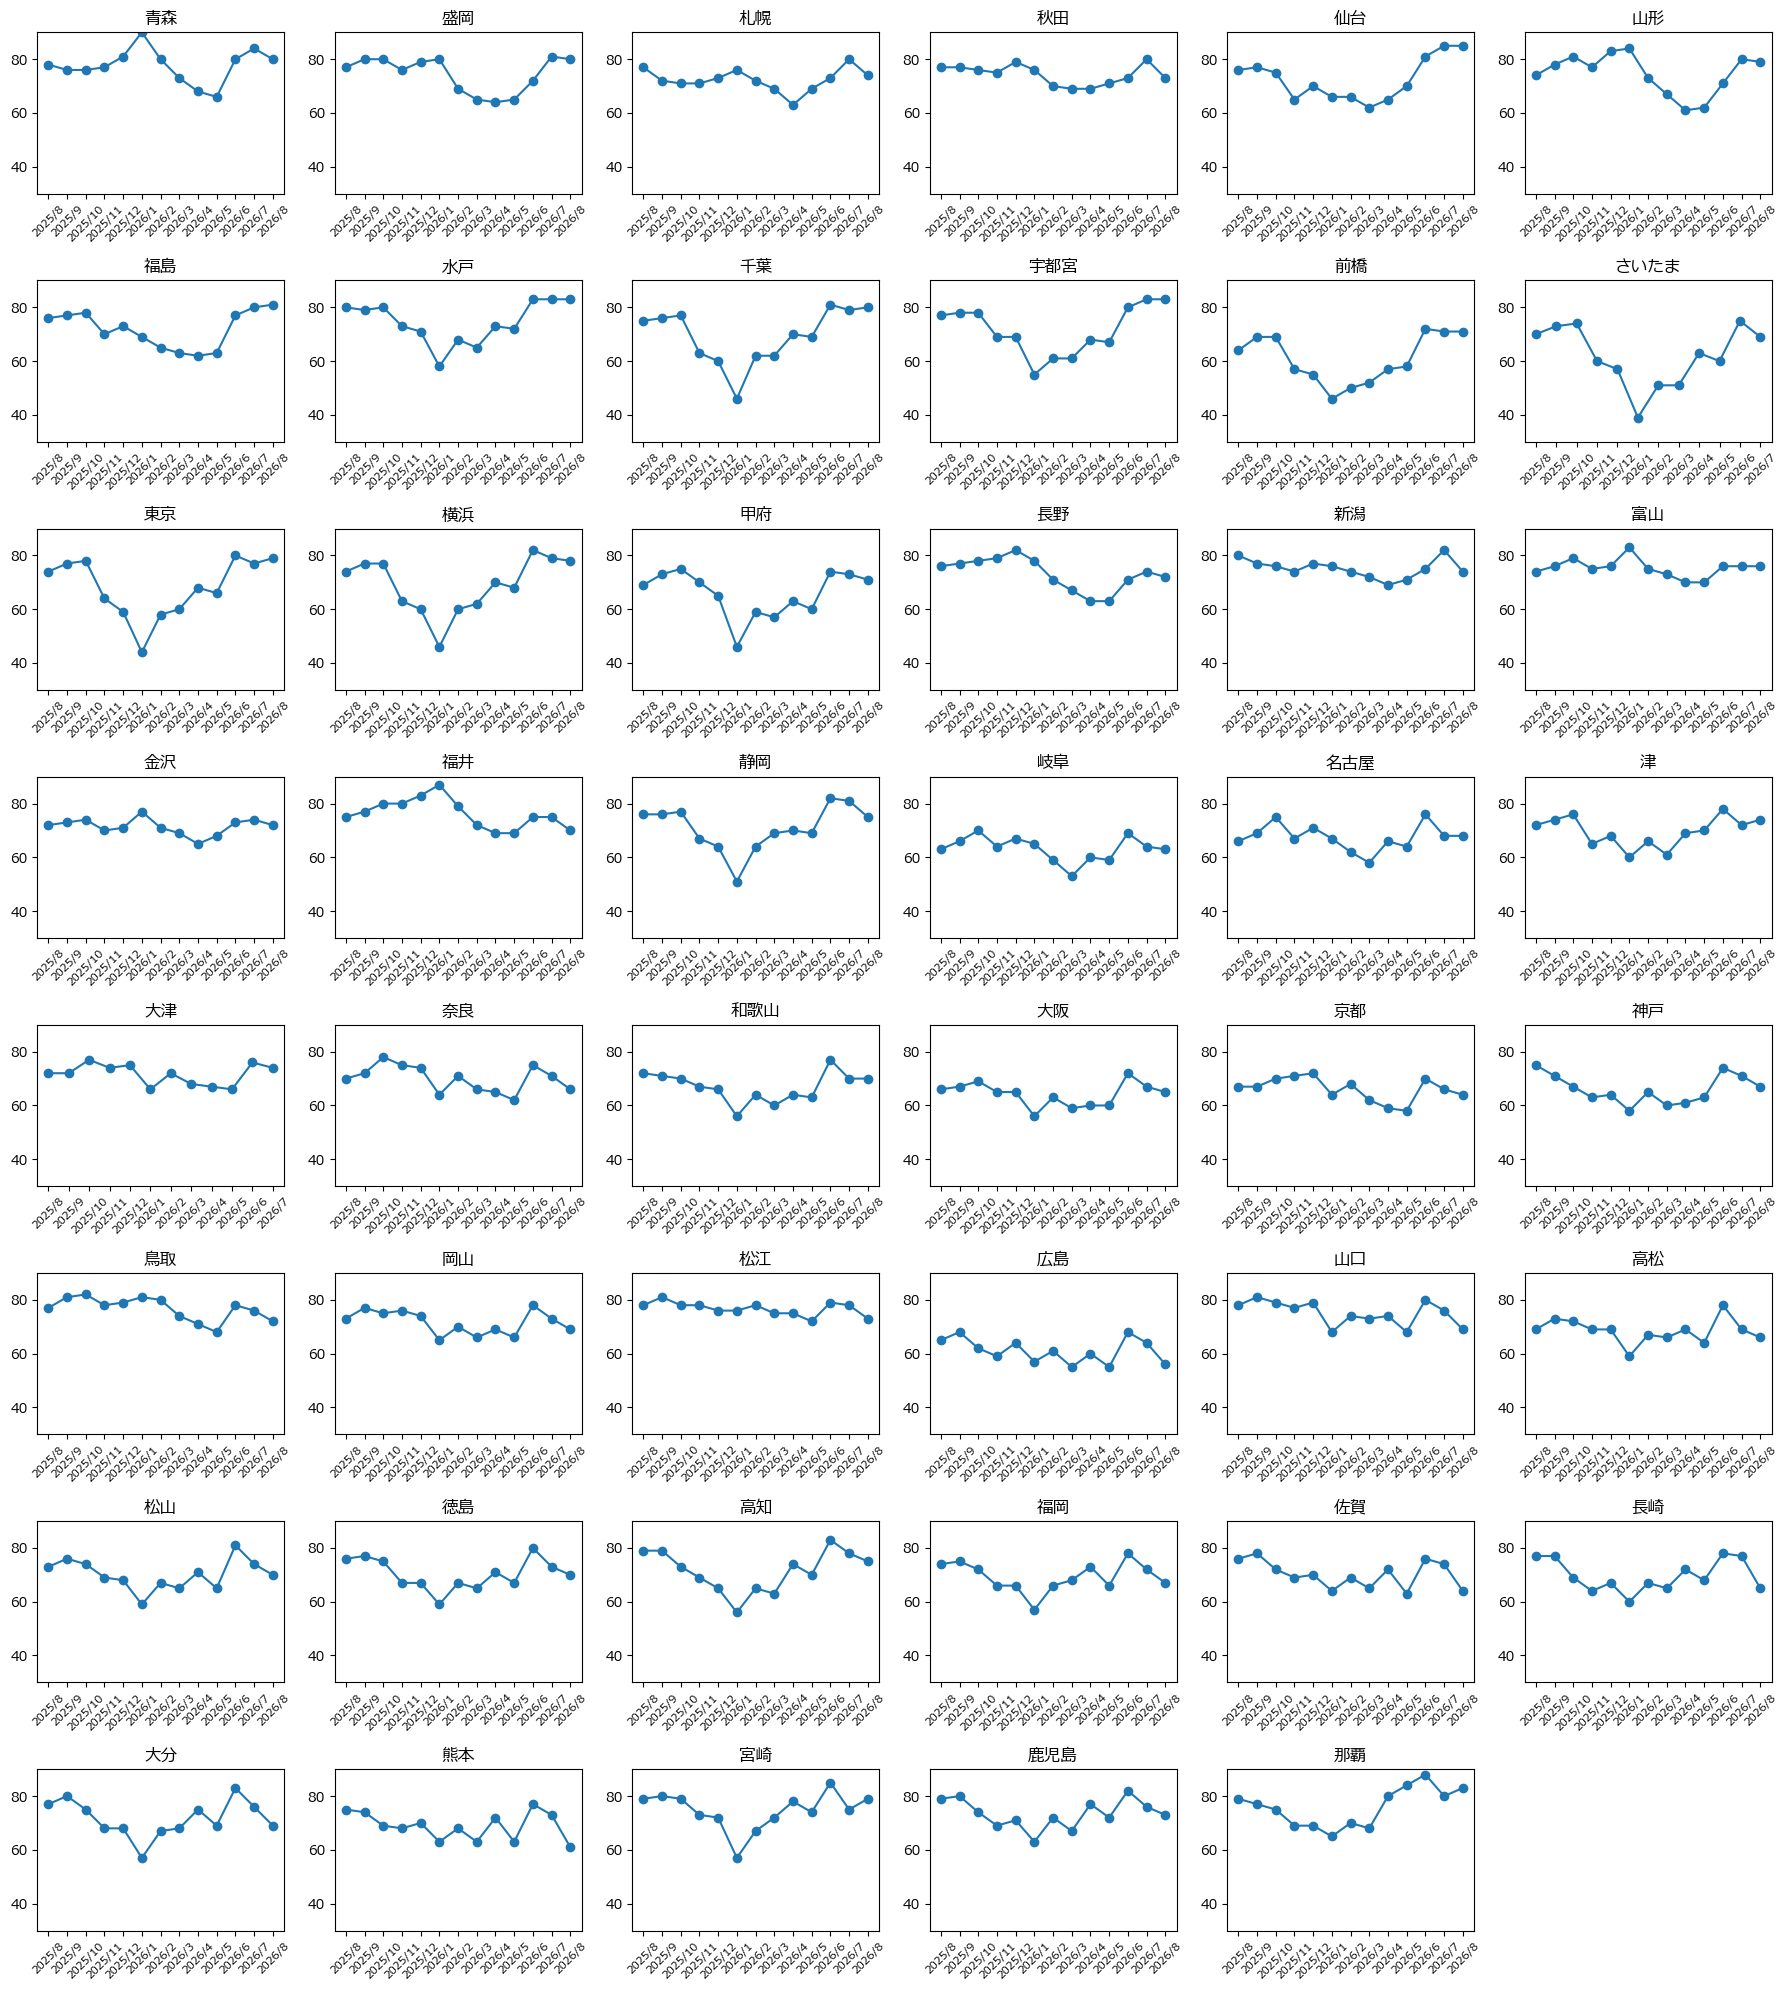

In [26]:
### 湿度 ###

# グラフの行数・列数指定
n_rows = 8
n_cols = 6
# 都市数を取得
# 都市数を取得
n_cities = len(df_air_humidity.index)

# 8×6のグラフ領域を作成
fig, ax = plt.subplots(n_rows, n_cols, figsize=(18, 20))

# 都市ごとにグラフを作成
### ループでインデックスを取得 enumerate()
for i, city in enumerate(df_air_humidity.index):

    # i番目の都市を配置する行番号を計算 (//で割り算の整数除算)
    row = i // n_cols
    # i番目の都市を配置する列番号を計算（%で割り算のあまり）
    col = i % n_cols

    # 該当するグラフ枠に平均湿度の推移をプロット
    ax[row][col].plot(
        df_air_humidity.columns,      # x軸：年月
        df_air_humidity.loc[city],    # y軸：その都市の平均湿度
        marker="o"                    # マーカーを丸に
    )

    # グラフのタイトルに都市名を設定
    ax[row][col].set_title(city)

    # 縦軸の範囲を統一
    ax[row][col].set_ylim(30, 90)

    # x軸の年月を45度回転
    ax[row][col].tick_params(
        axis="x",
        rotation=45,
        labelsize=8
    )

# 都市数より多い余分なグラフ枠を非表示
for i in range(n_cities, n_rows * n_cols):

    # 余ったグラフ枠の行番号を計算
    row = i // n_cols
    # 余ったグラフ枠の列番号を計算
    col = i % n_cols

    # グラフ枠を非表示にする
    ax[row][col].set_visible(False)

# グラフ同士の余白を自動調整
plt.tight_layout()

# グラフを表示
plt.show()

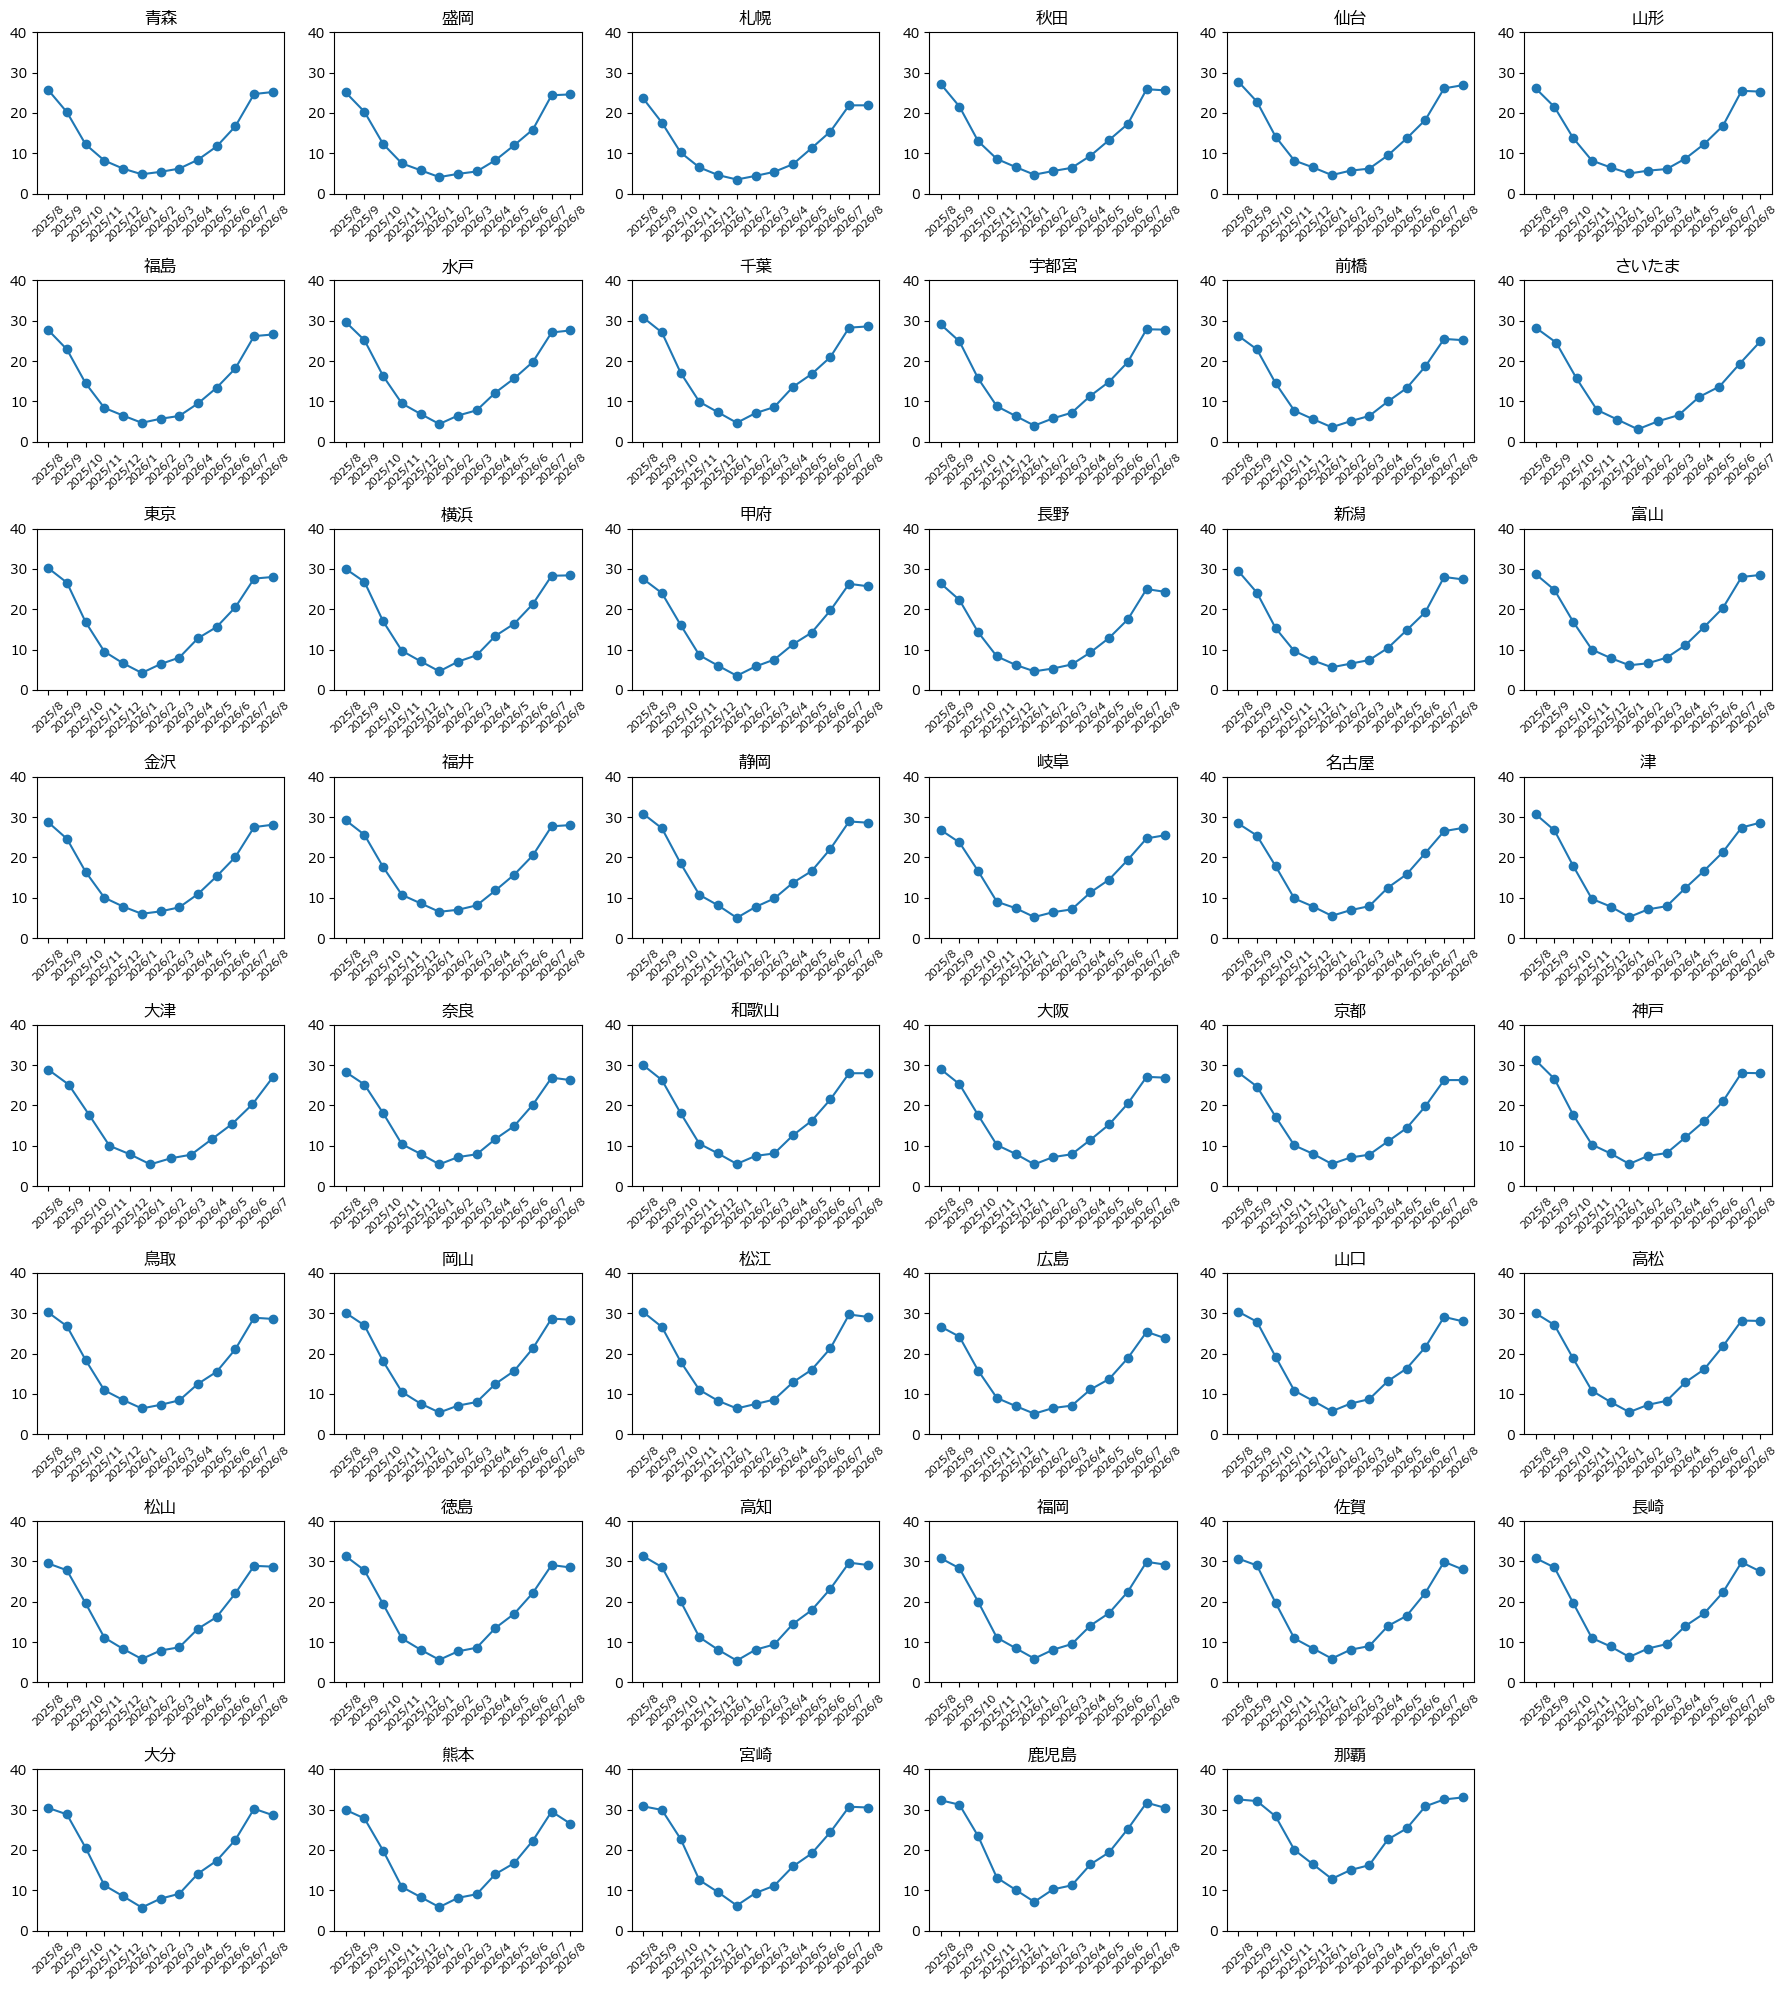

In [27]:
### 湿度 ###

# グラフの行数・列数指定
n_rows = 8
n_cols = 6
# 都市数を取得
# 都市数を取得
n_cities = len(df_vapor_pressure.index)

# 8×6のグラフ領域を作成
fig, ax = plt.subplots(n_rows, n_cols, figsize=(18, 20))

# 都市ごとにグラフを作成
### ループでインデックスを取得 enumerate()
for i, city in enumerate(df_vapor_pressure.index):

    # i番目の都市を配置する行番号を計算 (//で割り算の整数除算)
    row = i // n_cols
    # i番目の都市を配置する列番号を計算（%で割り算のあまり）
    col = i % n_cols

    # 該当するグラフ枠に平均湿度の推移をプロット
    ax[row][col].plot(
        df_vapor_pressure.columns,      # x軸：年月
        df_vapor_pressure.loc[city],    # y軸：その都市の平均湿度
        marker="o"                    # マーカーを丸に
    )

    # グラフのタイトルに都市名を設定
    ax[row][col].set_title(city)

    # 縦軸の範囲を統一
    ax[row][col].set_ylim(0, 40)

    # x軸の年月を45度回転
    ax[row][col].tick_params(
        axis="x",
        rotation=45,
        labelsize=8
    )

# 都市数より多い余分なグラフ枠を非表示
for i in range(n_cities, n_rows * n_cols):

    # 余ったグラフ枠の行番号を計算
    row = i // n_cols
    # 余ったグラフ枠の列番号を計算
    col = i % n_cols

    # グラフ枠を非表示にする
    ax[row][col].set_visible(False)

# グラフ同士の余白を自動調整
plt.tight_layout()

# グラフを表示
plt.show()

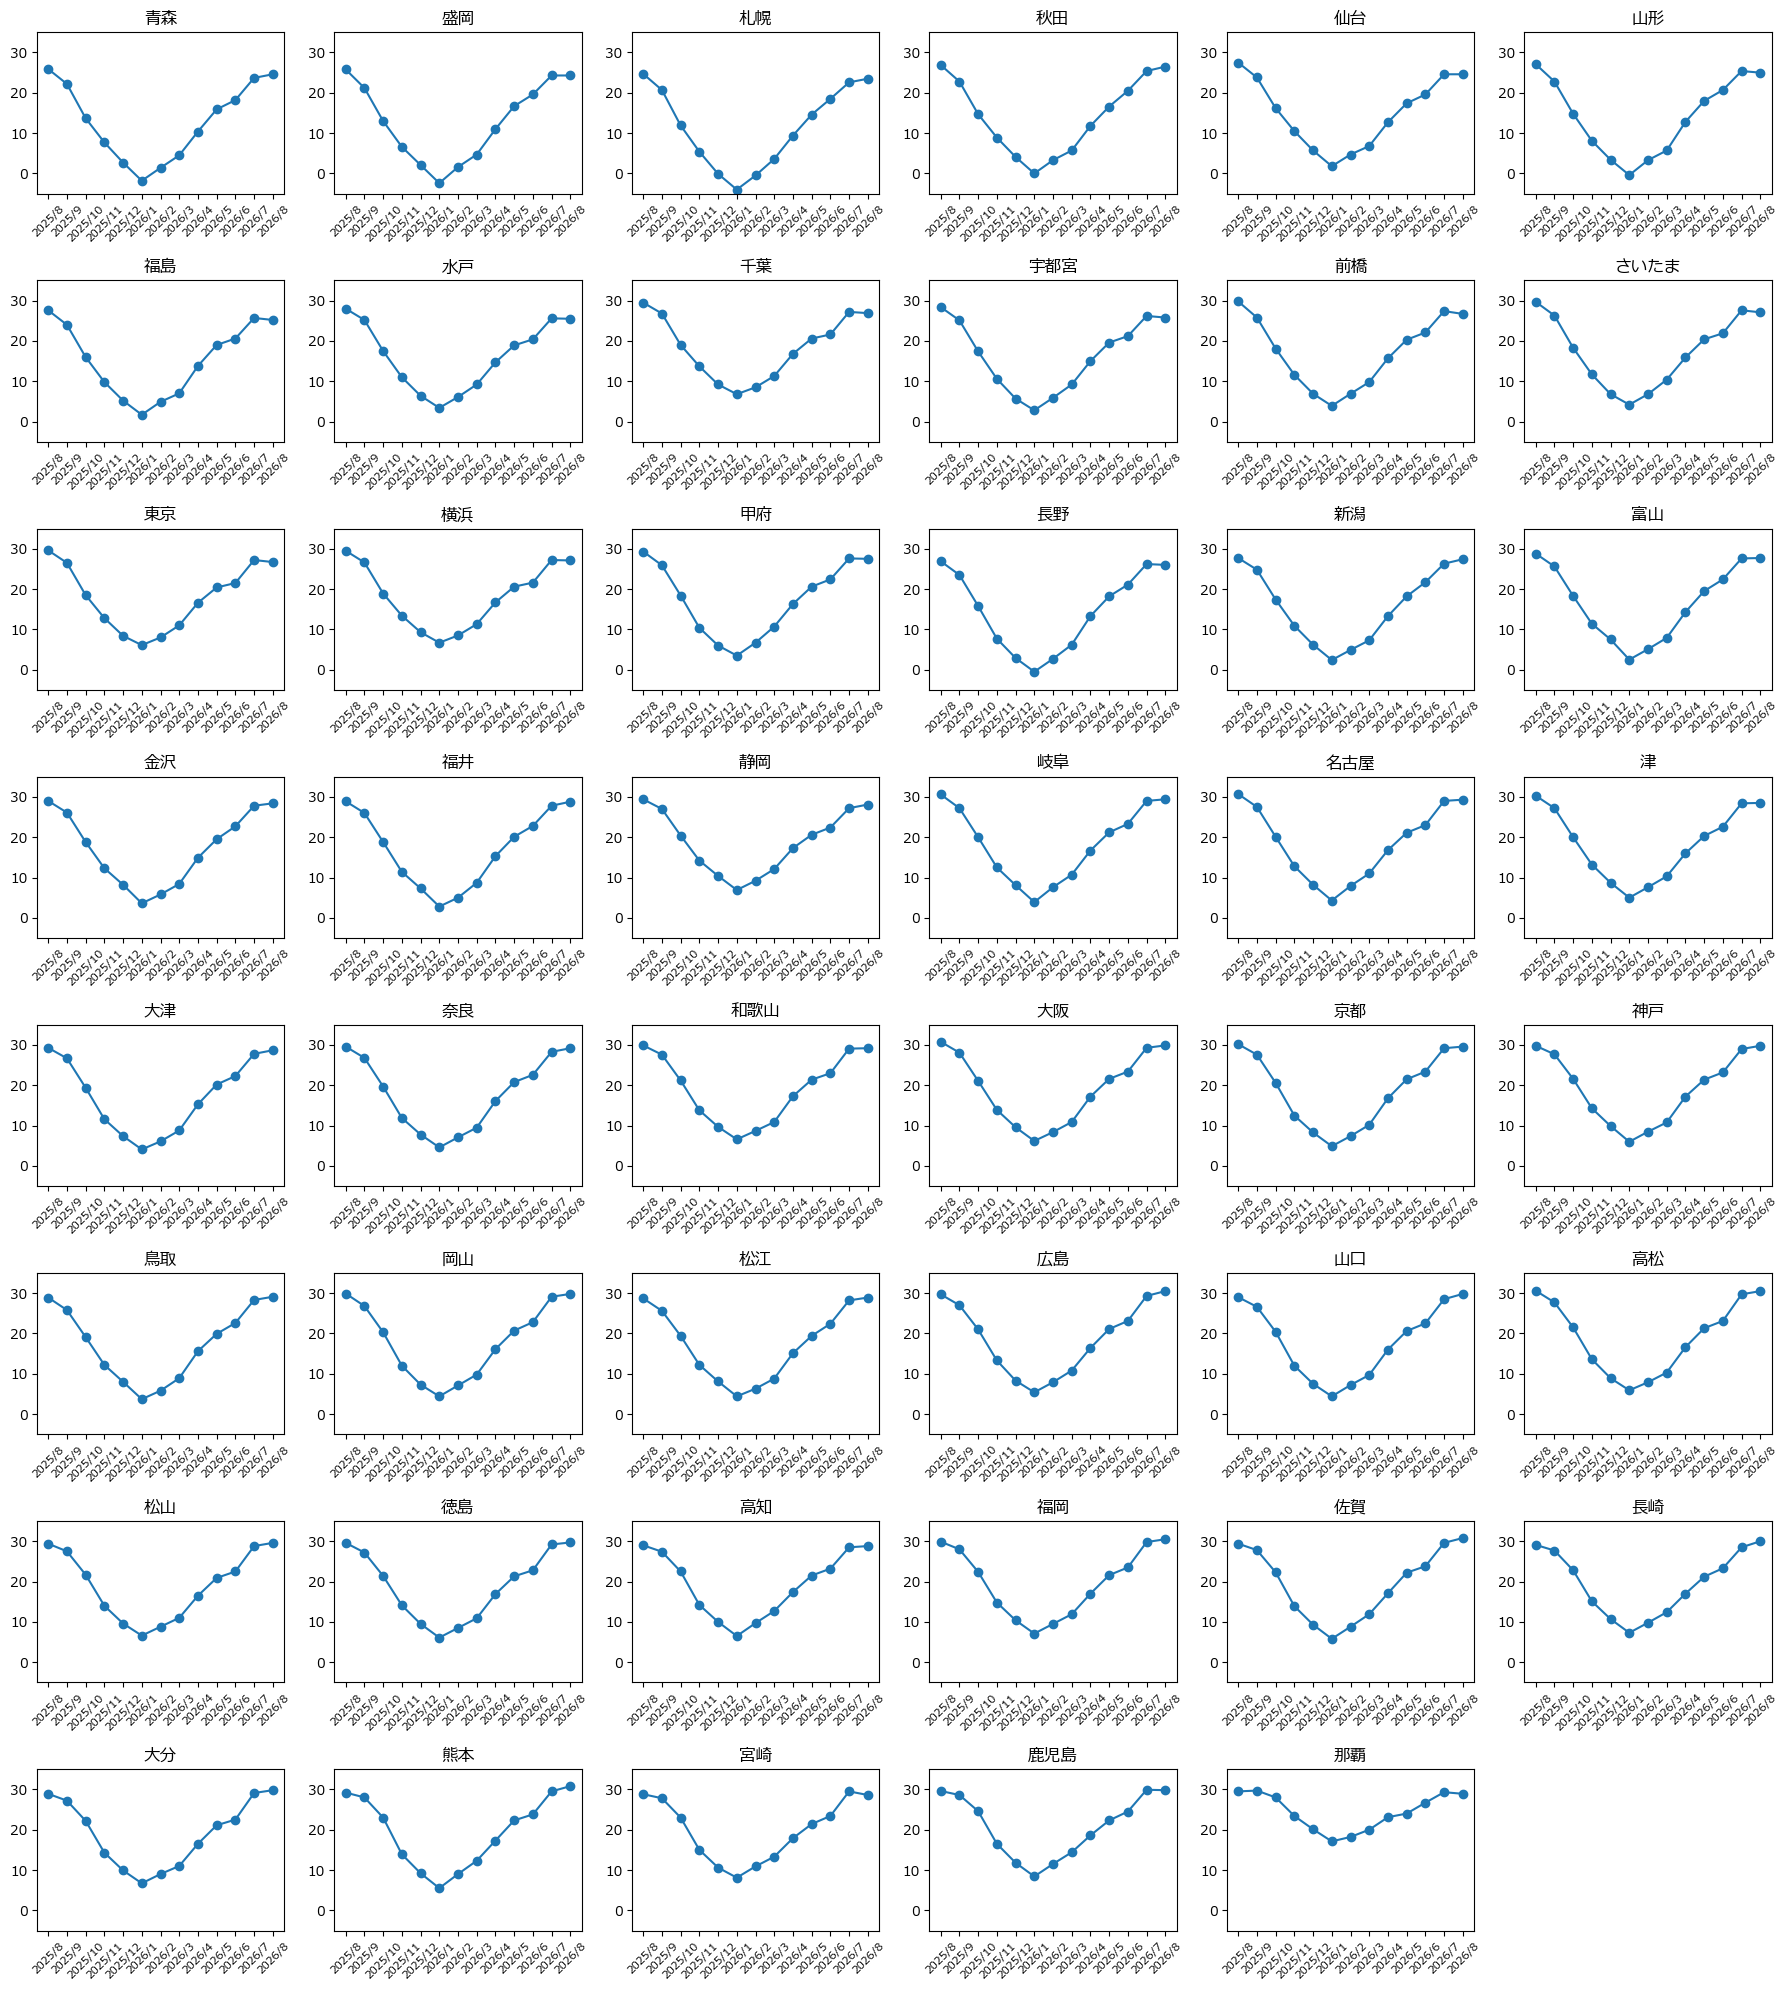

In [28]:
### 気温 ###

# グラフの行数・列数指定
n_rows = 8
n_cols = 6
# 都市数を取得
# 都市数を取得
n_cities = len(df_air_temp.index)

# 8×6のグラフ領域を作成
fig, ax = plt.subplots(n_rows, n_cols, figsize=(18, 20))

# 都市ごとにグラフを作成
### ループでインデックスを取得 enumerate()
for i, city in enumerate(df_air_temp.index):

    # i番目の都市を配置する行番号を計算 (//で割り算の整数除算)
    row = i // n_cols
    # i番目の都市を配置する列番号を計算（%で割り算のあまり）
    col = i % n_cols

    # 該当するグラフ枠に平均湿度の推移をプロット
    ax[row][col].plot(
        df_air_temp.columns,      # x軸：年月
        df_air_temp.loc[city],    # y軸：その都市の平均湿度
        marker="o"                    # マーカーを丸に
    )

    # グラフのタイトルに都市名を設定
    ax[row][col].set_title(city)

    # 縦軸の範囲を統一
    ax[row][col].set_ylim(-5, 35)

    # x軸の年月を45度回転
    ax[row][col].tick_params(
        axis="x",
        rotation=45,
        labelsize=8
    )

# 都市数より多い余分なグラフ枠を非表示
for i in range(n_cities, n_rows * n_cols):

    # 余ったグラフ枠の行番号を計算
    row = i // n_cols
    # 余ったグラフ枠の列番号を計算
    col = i % n_cols

    # グラフ枠を非表示にする
    ax[row][col].set_visible(False)

# グラフ同士の余白を自動調整
plt.tight_layout()

# グラフを表示
plt.show()

#### 可視化に対する考察
##### 湿度
- 盛岡の冬が特に乾燥しているというわけではない
- 年ごとに湿度分布に大きな特徴が見られる
- 　→　ぜひともこの「年間湿度の分布」を採用したい
##### 蒸気圧
- 大気の湿り気を表す指標として追加調査したものの、分布には大きな違いは見られない
- 盛岡はまぁ冬季前後の蒸気圧変化がゆるいかなーという感じ
##### 気温
- 湿度で盛岡が乾燥していると結論付けられなかったため追加で調査したものの、こちらも47都市的に分布の違いはなし

##### 「湿度」より、以下2つの指標を採用したい。
- 47都市平均との差 (√平方和　→　ユークリッド距離)　
- 盛岡と各都市の相関係数

In [29]:
# 47都市平均との差（ユークリッド距離）
### ① 47都市の各月平均
humidity_mean = df_air_humidity.mean(axis=0)

### ② 各都市の47都市平均からのユークリッド距離
humidity_distance = (
    (df_air_humidity - humidity_mean)
    .pow(2)
    .sum(axis=1)
    .pow(0.5)
)

In [30]:
# 各都市と盛岡市の月別湿度の相関係数
humidity_corr_morioka = df_air_humidity.T.corr()["盛岡"]

In [31]:
# 湿度に関する2つの指標をDataFrame化
df_humidity_pattern = pd.DataFrame({
    "湿度パターン距離": humidity_distance,
    "盛岡との相関": humidity_corr_morioka
})

# 都市名を列にする
df_humidity_pattern.index.name = "都市"
df_humidity_pattern = df_humidity_pattern.reset_index()

In [34]:
# 集計結果を県庁所在地データにマージ
df_analysis_air = df_prefectural_capitals.merge(
    df_humidity_pattern,
    on="都市",
    how="left"
)
df_analysis_air.head(3)

,コード,都道府県,県庁所在地,ローマ字,都市,湿度パターン距離,盛岡との相関
0,1,北海道,札幌市,sapporo,札幌,17.585127,0.738040
1,2,青森県,青森市,aomori,青森,35.376293,0.715897
2,3,岩手県,盛岡市,morioka,盛岡,24.064920,1.000000


In [39]:
# csv出力
# 加工済みデータ
df_air_humidity.to_csv("../data/data_air_humidity.csv", encoding='shift_jis')
# 集計結果
df_analysis_air.to_csv("../data/df_analysis_air_humidity.csv", encoding='shift_jis')